# Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

# Importing Data Set

In [4]:
heart = pd.read_csv('heart.csv')

# Understanding the data set

In [6]:
heart.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40.0,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49.0,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37.0,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48.0,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54.0,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [7]:
heart.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45.0,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68.0,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57.0,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57.0,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38.0,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


# Knowing size/dimension of data set

In [9]:
heart.shape

(918, 12)

# Finding Null Values

In [11]:
heart.isnull().sum()

Age               4
Sex               3
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

# Description of data set

In [13]:
heart.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,914.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.553611,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.424972,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [14]:
heart.describe(include = 'all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,914.000000,915,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,723,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.553611,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.424972,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


# Handling Null Values

In [16]:
# Replacing null values of Age column with mean value from describe function o/p
heart['Age'].fillna(53.6,inplace = True)

In [17]:
# OR for above
# heart['Age'].fillna(np.mean(heart['Age']),inplace = True)

In [18]:
# Replacing null values of Sex column with Mode value from describe function o/p
heart['Sex'].fillna('M', inplace = True)

In [19]:
heart.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [20]:
heart.dtypes

Age               float64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

# Finding unique values of few columns

In [22]:
cp = heart['ChestPainType'].value_counts()

In [23]:
ecg = heart['RestingECG'].value_counts()

In [24]:
ex_ang = heart['ExerciseAngina'].value_counts()

In [25]:
slope = heart['ST_Slope'].value_counts()

In [26]:
dis_count = heart['HeartDisease'].value_counts()

In [27]:
gender = heart.Sex.value_counts()
gender

Sex
M    726
F    192
Name: count, dtype: int64

# Exploratory Data Aanlysis

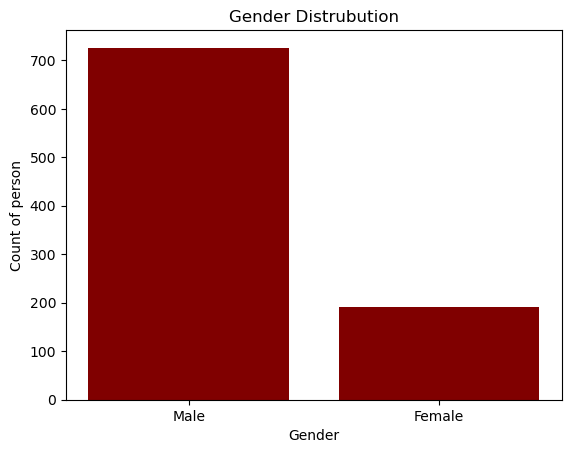

In [29]:
plt.bar(['Male','Female'], gender.values, color = 'Maroon')
plt.xlabel("Gender")
plt.ylabel('Count of person')
plt.title("Gender Distrubution")
plt.show()

In [30]:
# The above graph shows there are more male patients than female patients

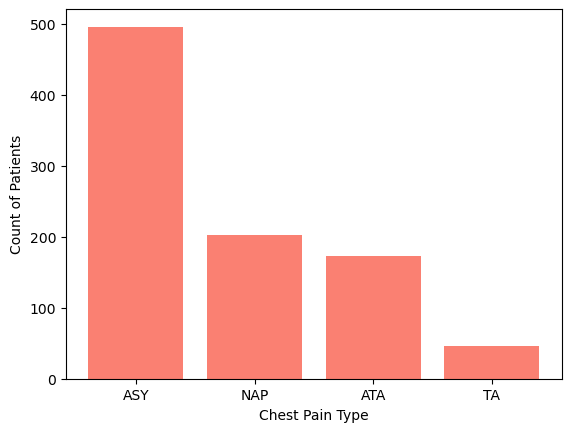

In [31]:
# Distribution of chest pain types 
plt.bar(cp.index , cp.values , color='Salmon')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count of Patients')
plt.show()

In [32]:
# The above graph shows that ASY is most common type of chest pain

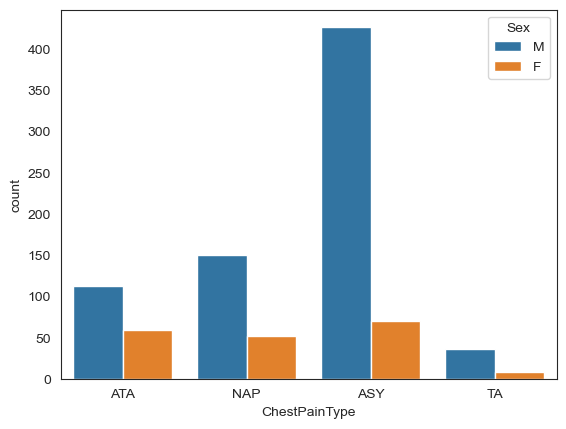

In [33]:
# Distribution of types of chest pain on gender
sns.set_style('white')
sns.countplot( x='ChestPainType' , hue='Sex' , data=heart)
plt.show()

In [34]:
# The above graph shows that ASY is most common type of chest pain among men and TA is rarest among women

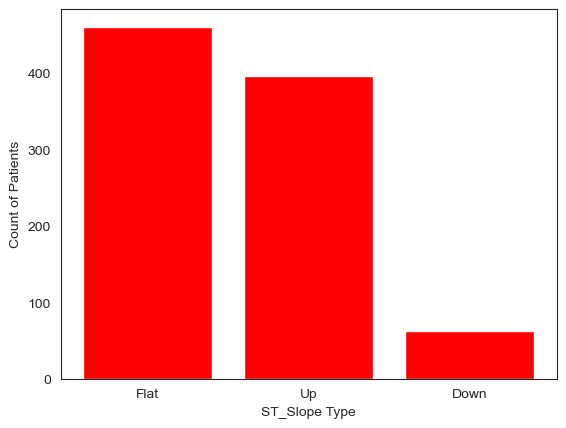

In [35]:
# Distribution of ST_Slope types 
plt.bar(slope.index , slope.values , color='Red')
plt.xlabel('ST_Slope Type')
plt.ylabel('Count of Patients')
plt.show()

In [36]:
# Above graphy shows that flat is most common type pf slope

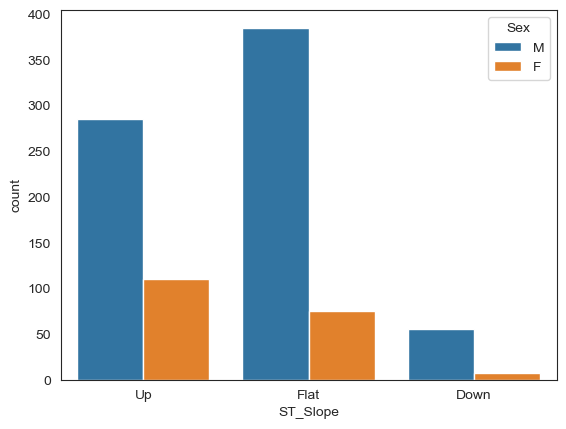

In [37]:
# Distribution of types of ST_Slope on gender
sns.set_style('white')
sns.countplot( x='ST_Slope' , hue='Sex' , data=heart)
plt.show()

In [38]:
# Above graphy shows that flat is most common type pf slope among men

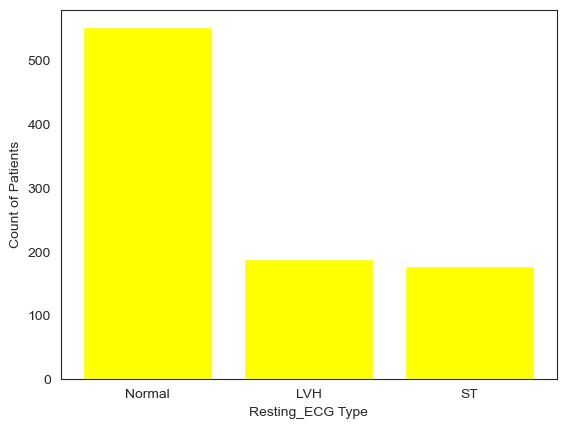

In [39]:
# Distribution of Resting ECG types 
plt.bar(ecg.index , ecg.values , color='yellow')
plt.xlabel('Resting_ECG Type')
plt.ylabel('Count of Patients')
plt.show()

In [182]:
# Above graphy shows that maximum patients have normal resting ECG type and LVH and ST type are almost smae

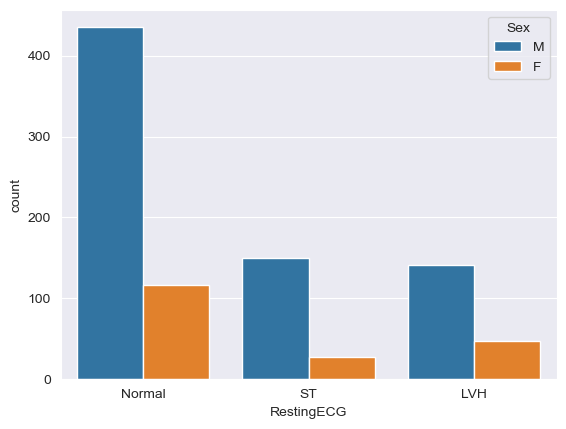

In [40]:
# Distribution of types of resting ECG on gender
sns.set_style('darkgrid')
sns.countplot( x='RestingECG' , hue='Sex' , data=heart)
plt.show()

In [184]:
# Above graphy shows that maximum number of both males and females have normal resting ECG

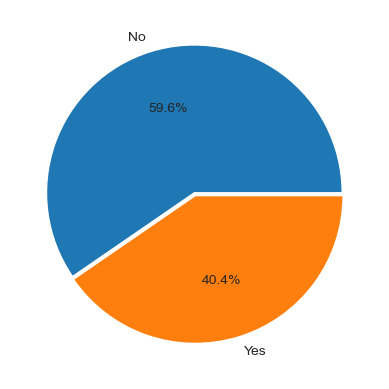

In [41]:
# Distribution of Exercise Angina types 
plt.pie(ex_ang.values , labels = ['No','Yes'] , autopct = '%0.1f%%' , explode = [0.01,0.01])
plt.show()

In [186]:
# Above graphy shows that maximum nimber of patients do not have exercise angina

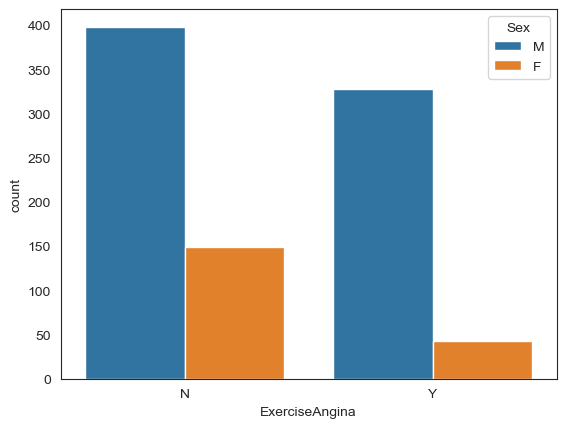

In [42]:
# Distribution of presence of Exercise Angina on gender
sns.set_style('white')
sns.countplot( x='ExerciseAngina' , hue='Sex' , data=heart)
plt.show()

In [188]:
# Above graphy shows that very less number of females have excercise angine as compared to women

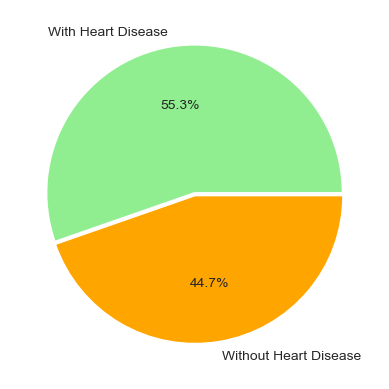

In [43]:
# Distribution ofpresence of heart disease 
plt.pie(dis_count.values , labels = ['With Heart Disease', 'Without Heart Disease'], autopct = '%0.1f%%' , explode = [0.01,0.01],
       colors = ['Lightgreen','Orange'])
plt.show()

In [190]:
# Above graphy shows that proportion of people with and without disease have no much differnece

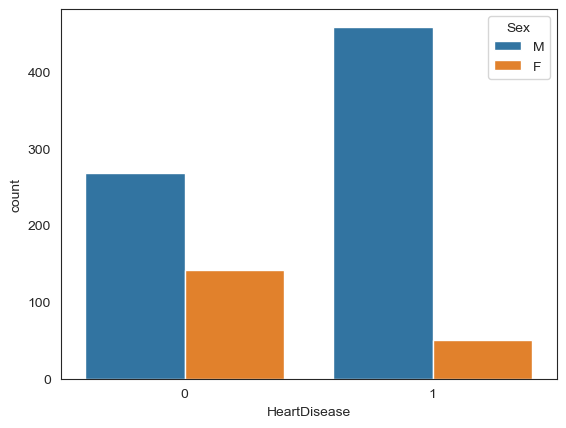

In [44]:
# Distribution of presence of heart disease on gender
sns.set_style('white')
sns.countplot( x='HeartDisease' , hue='Sex' , data=heart)
plt.show()

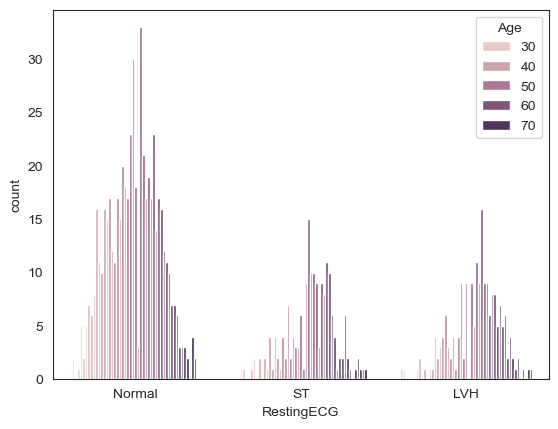

In [45]:
# Distribution of types of resting ECG on age
sns.set_style('white')
sns.countplot( x='RestingECG' , hue='Age' , data=heart)
plt.show()

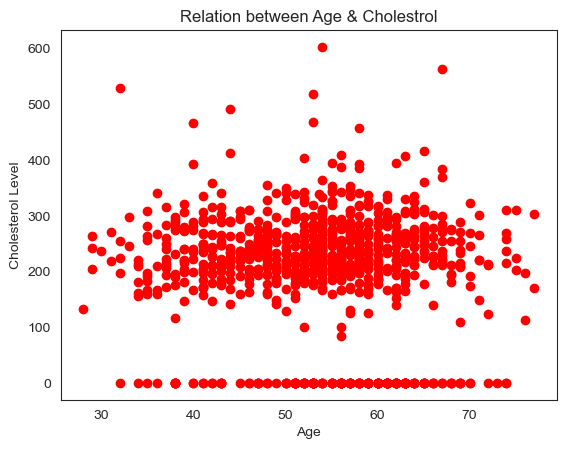

In [46]:
# Relationship between cholestrol and age
plt.scatter(heart['Age'], heart['Cholesterol'], color = 'Red')
plt.title('Relation between Age & Cholestrol')
plt.xlabel('Age')
plt.ylabel('Cholesterol Level')
plt.show()

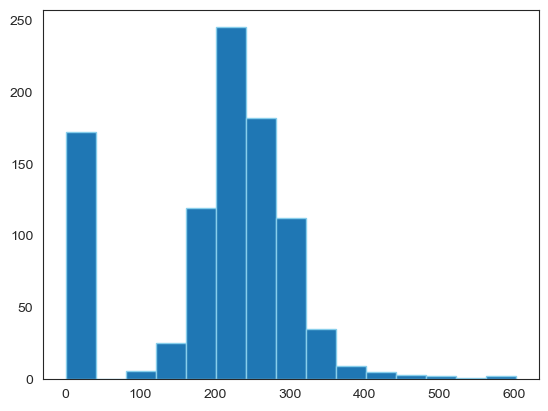

In [47]:
# Distribution of Cholestrol
plt.hist(heart['Cholesterol'],bins=15,edgecolor = 'Skyblue')
plt.show()

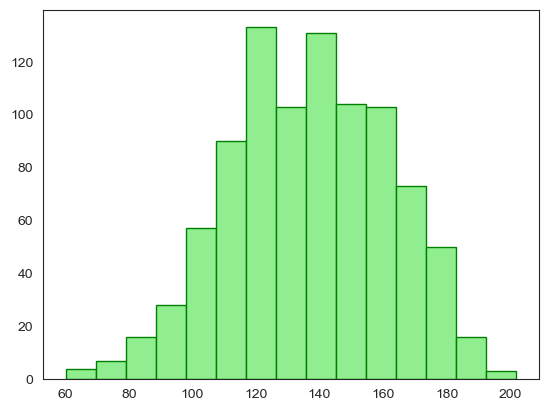

In [48]:
# Distribution of Heart Rate
plt.hist(heart.MaxHR , bins=15 , color = 'lightgreen' , edgecolor= 'green')
plt.show()

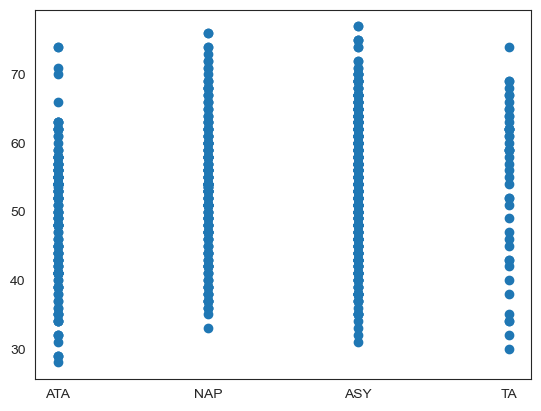

In [49]:
# Dependency of Age and Chest Pain Type
plt.scatter(heart.ChestPainType, heart.Age)
plt.show()

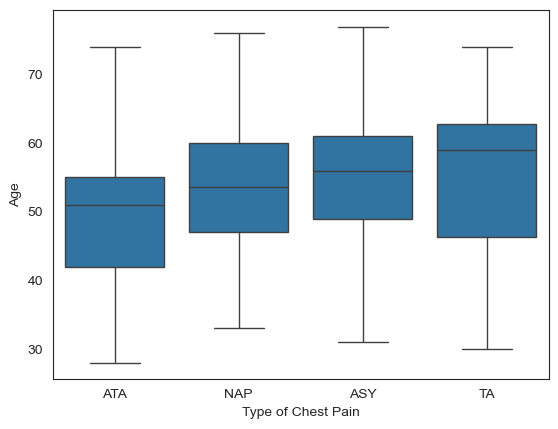

In [50]:
# OR
sns.boxplot(x = 'ChestPainType' , y='Age' , data = heart)
plt.xlabel('Type of Chest Pain')
plt.ylabel('Age')
plt.show()

In [51]:
# Clearly no such relationship

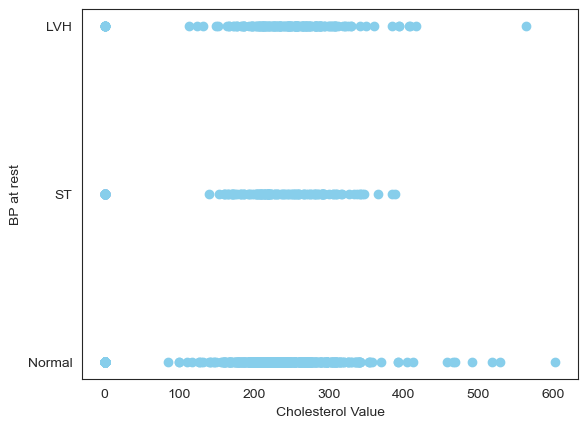

In [52]:
# Relation btw cholestrol and reatingECG
plt.scatter(heart.Cholesterol , heart.RestingECG , color = 'skyblue')
plt.xlabel('Cholesterol Value')
plt.ylabel('BP at rest')
plt.show()

In [53]:
# The graph shows that their is no conclusive evidence stating BP changes due to cholesterol

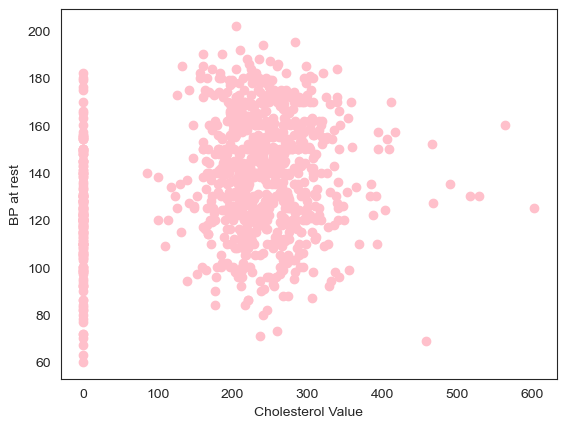

In [54]:
# Relation btw cholestrol and heart rate
plt.scatter(heart.Cholesterol , heart.MaxHR, color = 'pink')
plt.xlabel('Cholesterol Value')
plt.ylabel('BP at rest')
plt.show()

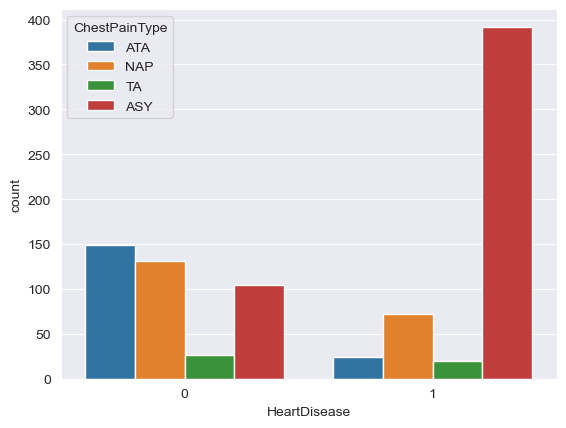

In [55]:
sns.set_style('darkgrid')
sns.countplot(x='HeartDisease' , hue = 'ChestPainType' , data = heart)
plt.show()

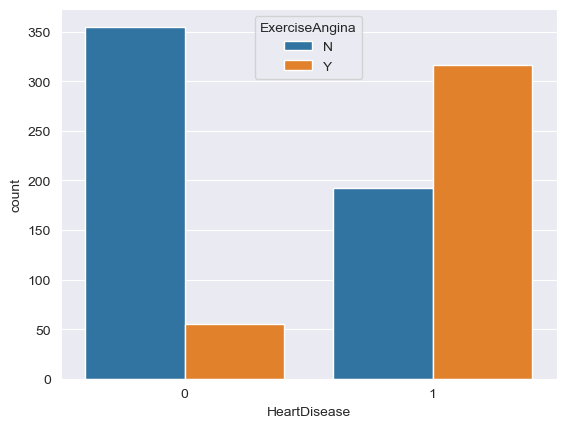

In [56]:
sns.set_style('darkgrid')
sns.countplot(x='HeartDisease' , hue = 'ExerciseAngina' , data = heart)
plt.show()

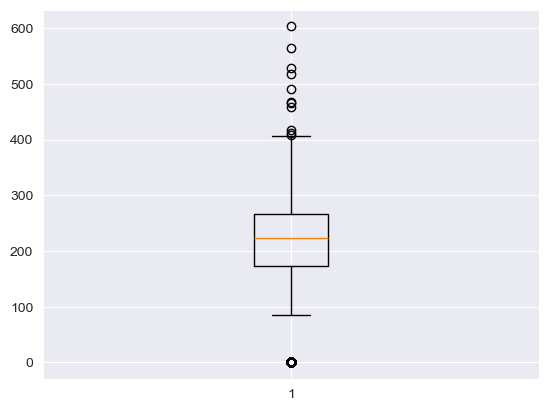

In [57]:
plt.boxplot(heart.Cholesterol)
plt.show()

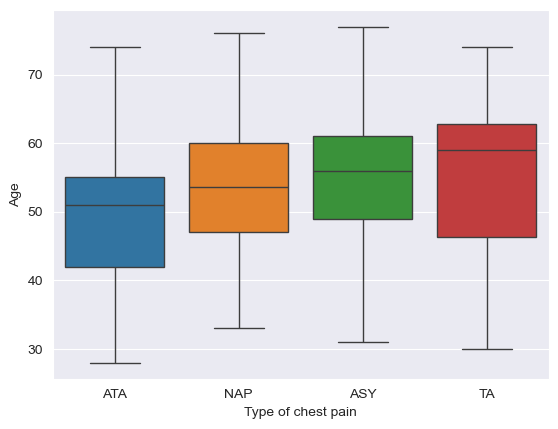

In [58]:
sns.boxplot(x = 'ChestPainType', y='Age', data=heart, hue = 'ChestPainType')
plt.xlabel('Type of chest pain')
plt.ylabel('Age')
plt.show()

# Machine Learning 

# Encoding

In [61]:
from sklearn.preprocessing import LabelEncoder

In [62]:
encode = LabelEncoder()
heart['Sex'] = encode.fit_transform(heart['Sex'])
heart.ChestPainType = encode.fit_transform(heart.ChestPainType)
heart.RestingECG = encode.fit_transform(heart.RestingECG)
heart.ExerciseAngina = encode.fit_transform(heart.ExerciseAngina)
heart.ST_Slope = encode.fit_transform(heart.ST_Slope)

# Splitting of the data

In [64]:
X = heart.iloc[: , :-1]
y = heart.HeartDisease

In [65]:
x_tr, x_te, y_tr, y_te = train_test_split(X,y,test_size = 0.25)
print(x_tr.shape)
print(x_te.shape)
print(y_tr.shape)
print(y_te.shape)

(688, 11)
(230, 11)
(688,)
(230,)


# Logistic Regression
-Classification

In [67]:
from sklearn.linear_model import LogisticRegression

In [68]:
model = LogisticRegression()
model.fit(x_tr,y_tr)

LogisticRegression()

In [69]:
y_pred = model.predict(x_te)

In [70]:
from sklearn.metrics import accuracy_score,confusion_matrix
print('The percentage accuracy of the model is:',accuracy_score(y_te, y_pred)*100)

The percentage accuracy of the model is: 83.91304347826087


In [71]:
accuracies = []
accuracies.append(accuracy_score(y_te, y_pred)*100)

# Decision Tree
- Classification 

In [73]:
from sklearn.tree import DecisionTreeClassifier

In [74]:
model = DecisionTreeClassifier(max_depth=4)
model.fit(x_tr,y_tr)

DecisionTreeClassifier(max_depth=4)

In [75]:
depth = [1,2,3,4,5,6,7,8,9,10,11,12]
des_accus = []
for i in depth:
    model = DecisionTreeClassifier( max_depth=i)
    model.fit(x_tr,y_tr)
    y_pred = model.predict(x_te)
    des_accus.append(accuracy_score(y_te,y_pred)*100)

In [76]:
for i in range(len(depth)):
    print(f"Accuracy of decision tree with depth {depth[i]} is {des_accus[i]}")

Accuracy of decision tree with depth 1 is 82.17391304347827
Accuracy of decision tree with depth 2 is 82.6086956521739
Accuracy of decision tree with depth 3 is 83.04347826086956
Accuracy of decision tree with depth 4 is 84.78260869565217
Accuracy of decision tree with depth 5 is 83.91304347826087
Accuracy of decision tree with depth 6 is 82.17391304347827
Accuracy of decision tree with depth 7 is 84.78260869565217
Accuracy of decision tree with depth 8 is 83.04347826086956
Accuracy of decision tree with depth 9 is 85.65217391304348
Accuracy of decision tree with depth 10 is 80.8695652173913
Accuracy of decision tree with depth 11 is 80.43478260869566
Accuracy of decision tree with depth 12 is 81.73913043478261


In [77]:
model = DecisionTreeClassifier(max_depth=3)
model.fit(x_tr, y_tr)
y_pr = model.predict(x_te)
acc = accuracy_score(y_te, y_pr)*100
accuracies.append(acc)

In [78]:
# By default criteria for decision tree impurity calculation is GINI
# We can change it to EMTROPY
depth = [1,2,3,4,5,6,7,8,9,10,11,12]
entr_accus= []
for i in depth:
    model = DecisionTreeClassifier(criterion= 'entropy', max_depth=i)
    model.fit(x_tr,y_tr)
    y_pred = model.predict(x_te)
    entr_accus.append(accuracy_score(y_te,y_pred)*100)

In [79]:
for i in range(len(depth)):
    print(f"Accuracy of decision tree with depth {depth[i]} is {entr_accus[i]}")

Accuracy of decision tree with depth 1 is 82.17391304347827
Accuracy of decision tree with depth 2 is 82.17391304347827
Accuracy of decision tree with depth 3 is 81.30434782608695
Accuracy of decision tree with depth 4 is 83.91304347826087
Accuracy of decision tree with depth 5 is 84.78260869565217
Accuracy of decision tree with depth 6 is 79.56521739130434
Accuracy of decision tree with depth 7 is 76.95652173913044
Accuracy of decision tree with depth 8 is 77.82608695652173
Accuracy of decision tree with depth 9 is 76.95652173913044
Accuracy of decision tree with depth 10 is 76.95652173913044
Accuracy of decision tree with depth 11 is 75.65217391304347
Accuracy of decision tree with depth 12 is 76.95652173913044


# KNN Model
- Classification & Regression 

In [81]:
from sklearn.neighbors import KNeighborsClassifier

In [82]:
model = KNeighborsClassifier()
model.fit(x_tr,y_tr)
y_pred = model.predict(x_te)
accuracy_score(y_te,y_pred)*100

70.43478260869566

In [83]:
# With different values of K

k_vals = [1,2,3,4,5,6,7,8,9,10]
accus = []
for i in k_vals:
    model = KNeighborsClassifier(i)
    model.fit(x_tr,y_tr)
    y_pred = model.predict(x_te)
    accus.append(accuracy_score(y_te,y_pred)*100)
accus

[65.65217391304347,
 66.08695652173913,
 71.30434782608695,
 68.26086956521739,
 70.43478260869566,
 71.30434782608695,
 72.17391304347827,
 70.0,
 72.17391304347827,
 68.26086956521739]

In [84]:
#Usig best value of K from above
model = KNeighborsClassifier(n_neighbors=6)
model.fit(x_tr, y_tr)
y_pred = model.predict(x_te)
accuracies.append(accuracy_score(y_te, y_pred)*100)

# Support Vector Machine
- Classification

In [86]:
from sklearn.svm import SVC

In [87]:
model = SVC()
model.fit(x_tr,y_tr)
y_pred = model.predict(x_te)
accuracies.append(accuracy_score(y_te,y_pred)*100)

# Naive Bayes
- Classification

In [89]:
from sklearn.naive_bayes import GaussianNB

In [90]:
model = GaussianNB()
model.fit(x_tr,y_tr)
y_pred = model.predict(x_te)
accuracies.append(accuracy_score(y_te,y_pred)*100)

# Ensemble Random Forest model
- Classification & Regression
- For classification it chooses the majority/ common result
- For regression it averages the prediction

In [92]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_tr, y_tr)
y_pred = model.predict(x_te)
accuracies.append(accuracy_score(y_te, y_pred)*100)
accuracies

[83.91304347826087,
 83.04347826086956,
 71.30434782608695,
 73.47826086956522,
 84.78260869565217,
 85.21739130434783]

# Hyper Parameter tunning using grid search CV

In [94]:
from sklearn.model_selection import GridSearchCV

In [95]:
max_feat = [0.2,0.5,1.0]
max_dep = [2,3,4,5,6,7]
param_grid = {'max_features':max_feat, 'max_depth':max_dep}

model = DecisionTreeClassifier()
cls = GridSearchCV(estimator=model, param_grid=param_grid, cv = 5, n_jobs=-1, verbose=2)

cls.fit(x_tr, y_tr)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7],
                         'max_features': [0.2, 0.5, 1.0]},
             verbose=2)

In [96]:
#Getting best parameter combination
cls.best_params_

{'max_depth': 6, 'max_features': 0.5}

In [97]:
#Tunning Decision tree with best parameters
model = DecisionTreeClassifier(max_depth=5, max_features=1.0)
model.fit(x_tr, y_tr)
y_pr = model.predict(x_te)
acc = accuracy_score(y_te, y_pr)*100
accuracies.append(acc)

# Accuracy Distribution of different models

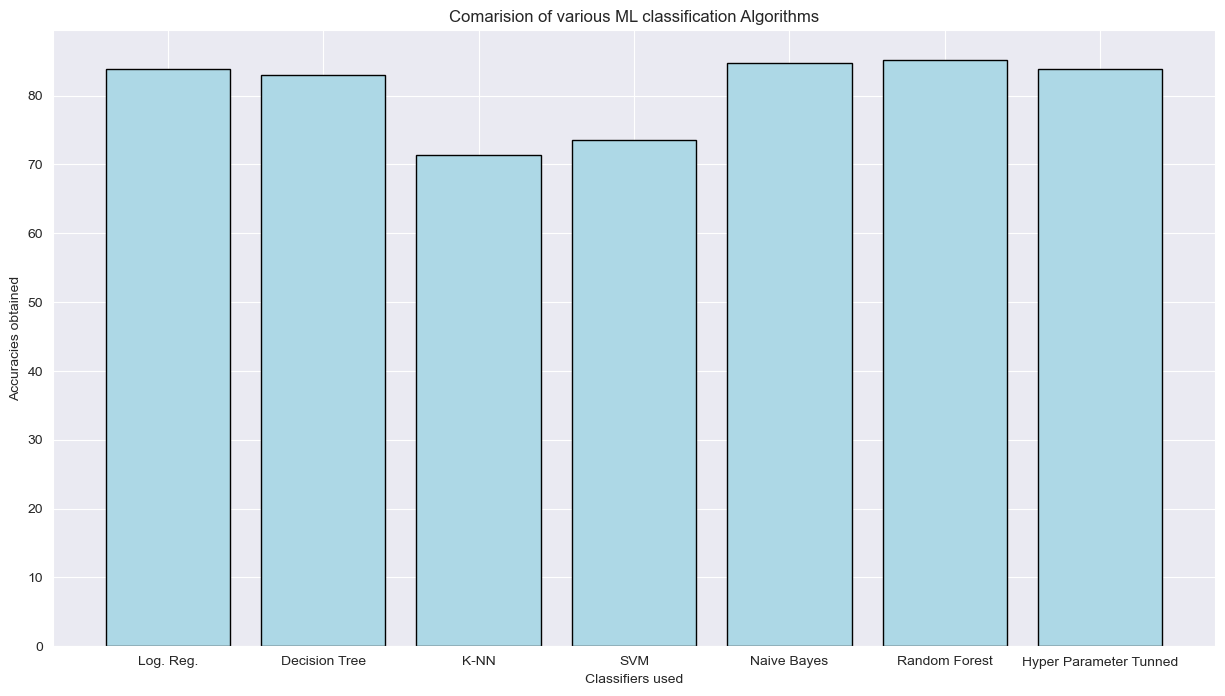

In [99]:
fig = plt.figure(figsize=(15,8))
classifiers = ['Log. Reg.','Decision Tree','K-NN','SVM','Naive Bayes','Random Forest','Hyper Parameter Tunned' ]
plt.bar(classifiers,accuracies, color = 'Lightblue',edgecolor = 'Black')
plt.xlabel("Classifiers used")
plt.ylabel("Accuracies obtained")
plt.title("Comarision of various ML classification Algorithms")
plt.show()